In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re

# 1. CARREGAR DADOS
df = pd.read_parquet("all_reviews.parquet")


In [11]:
df.head()

,review,score,product_name,source
0,Estou contente com a compra entrega rápida o ú...,4,Notebook Asus Vivobook Max X541NA-GO472T Intel...,b2w
1,"Por apenas R$1994.20,eu consegui comprar esse ...",4,Copo Acrílico Com Canudo 500ml Rocie,b2w
2,SUPERA EM AGILIDADE E PRATICIDADE OUTRAS PANEL...,4,Panela de Pressão Elétrica Philips Walita Dail...,b2w
3,MEU FILHO AMOU! PARECE DE VERDADE COM TANTOS D...,4,Betoneira Columbus - Roma Brinquedos,b2w
4,"A entrega foi no prazo, as americanas estão de...",5,"Smart TV LED 43"" LG 43UJ6525 Ultra HD 4K com C...",b2w


In [12]:
# usar apenas textos válidos
df = df.dropna(subset=["review"])

# 2. LIMPEZA
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zà-ú\s]', '', text)  # mantém letras
    return text

df["clean_text"] = df["review"].apply(clean_text)


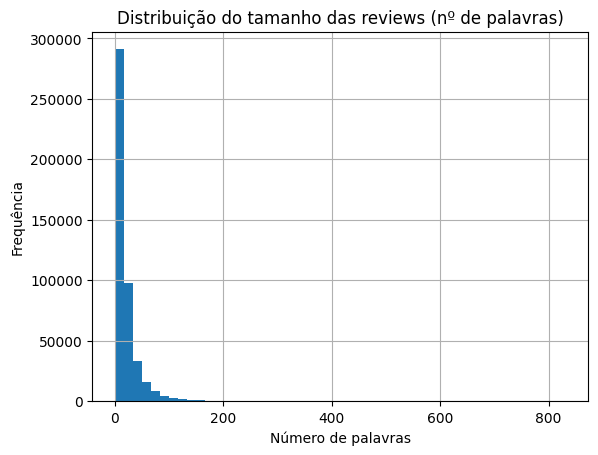

In [13]:
# 3. FEATURES
df["word_count"] = df["clean_text"].apply(lambda x: len(x.split()))

# 4. GRÁFICO 1: TAMANHO DOS TEXTOS
plt.figure()
df["word_count"].hist(bins=50)
plt.title("Distribuição do tamanho das reviews (nº de palavras)")
plt.xlabel("Número de palavras")
plt.ylabel("Frequência")
plt.show()


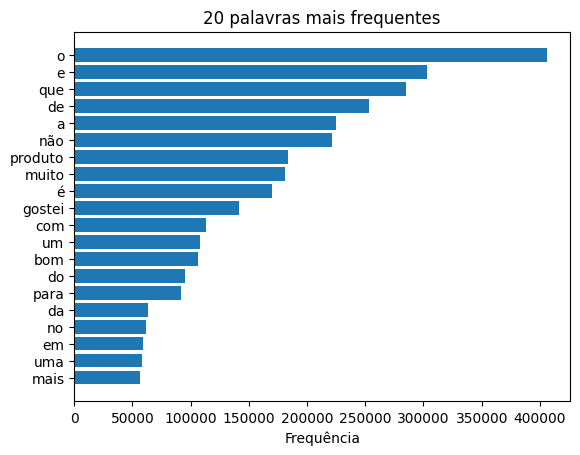

In [14]:
# 5. FREQUÊNCIA DE PALAVRAS
all_words = " ".join(df["clean_text"]).split()

word_freq = Counter(all_words).most_common(20)

words = [w[0] for w in word_freq]
counts = [w[1] for w in word_freq]

# 6. GRÁFICO 2: TOP PALAVRAS
plt.figure()
plt.barh(words, counts)
plt.title("20 palavras mais frequentes")
plt.xlabel("Frequência")
plt.gca().invert_yaxis()
plt.show()

In [15]:
# 7. ESTATÍSTICAS
vocab_size = len(set(all_words))
total_tokens = len(all_words)

print("Total de documentos:", len(df))
print("Total de palavras (tokens):", total_tokens)
print("Tamanho do vocabulário:", vocab_size)
print("Média de palavras por review:", df["word_count"].mean())

Total de documentos: 459560
Total de palavras (tokens): 9162516
Tamanho do vocabulário: 132120
Média de palavras por review: 19.937583775785534
